In [1]:
import logging

import numpy as np

import bot
import curling_nn
import data_generation
import dataset
import nn
import physics
import presets
import scoring
import state
from constants import STONE_RADIUS_M, center_of_target_house, house_outer_circle_radius

logging.basicConfig(level=logging.ERROR, format="%(message)s")
logger = logging.getLogger(__name__)
logging.getLogger("matplotlib.font_manager").setLevel(logging.WARNING)

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
neural_network = curling_nn.QNetwork(seed=0, num_stones=9, hidden_layer_size=20)
loss_function = nn.SoftmaxCrossEntropyLoss()

In [ ]:
# TODO: training data should have throws from both teams?
seed_states = data_generation.random_sheet_states(
    team1=5,
    team2=4,
    num_sims=1000,
)
data = data_generation.q_network_training_data(
    sheet_states=seed_states,
    team=1,
    rng=np.random.default_rng(0),
    n_random_throws=1,
    n_per_score=30,
)
print(f"dataset size: {data.size()}")


KeyboardInterrupt



In [ ]:
data, validation_data = data.partition(0.2, seed=0)

## categorical score predictor

In [ ]:
losses = []
val_losses = []
num_points_per_batch = 100
num_iters = 30

for i in range(num_iters):
    lr = 1 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in data.shuffle_batches(num_points_per_batch, seed=None):
        neural_network.train_batched(
            batch,
            loss_function,
            lr,
            0,
        )

    losses.append(
        neural_network.get_average_loss_batched(
            data.input_features, data.answers, loss_function
        )
    )
    val_losses.append(
        neural_network.get_average_loss_batched(
            validation_data.input_features, validation_data.answers, loss_function
        )
    )

In [ ]:
import constants

curling_nn.write_q_weights(
    constants.q_network_weights_path,
    neural_network,
    data.normalizer,
)
print(f"wrote weights to {constants.q_network_weights_path}")

In [7]:
validation_pred = nn.softmax(
    neural_network.run(validation_data.input_features[:, :, None])
)

In [8]:
validation_r2 = (
    1
    - ((validation_data.answers - validation_pred[:, :, 0]) ** 2).sum()
    / (validation_data.answers**2).sum()
)

In [9]:
validation_r2

np.float64(0.27461200861252477)

Loaded backend module://matplotlib_inline.backend_inline version unknown.
Loaded backend module://matplotlib_inline.backend_inline version unknown.


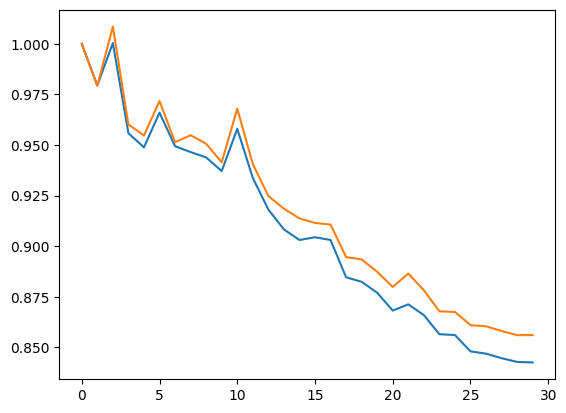

In [10]:
plt.plot(np.array(losses) / losses[0])
plt.plot(np.array(val_losses) / val_losses[0])

In [11]:
validation_loss = neural_network.get_average_loss_batched(
    validation_data.input_features, validation_data.answers, loss_function
)
print(validation_loss)

1.5239285367022715


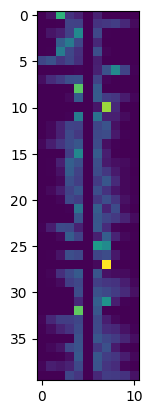

In [12]:
plt.imshow(validation_pred[:40, :, 0])

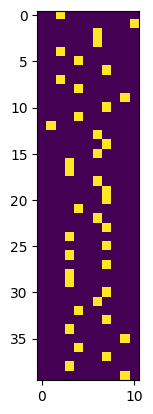

In [13]:
plt.imshow(validation_data.answers[:40, :])

In [14]:
pred_scores = neural_network.expected_score(
    neural_network.run(validation_data.input_features[:, :, None])
)
actual_scores = (validation_data.answers * np.arange(-5, 6).reshape((1, 11))).sum(
    axis=1
)

expected_score_val_r2 = (
    1 - ((actual_scores - pred_scores) ** 2).sum() / (actual_scores**2).sum()
)

frac_max_prob_eq_actual = (
    validation_pred.argmax(axis=1).flatten()
    == validation_data.answers.argmax(axis=1).flatten()
).mean()
print(
    f"expected_score_val_r2 = {expected_score_val_r2}, frac max prob = actual {frac_max_prob_eq_actual}"
)

expected_score_val_r2 = 0.38598243522322495, frac max prob = actual 0.3497294841614009


In [16]:
(1 - (actual_scores - pred_scores) ** 2 / actual_scores**2).std() / 200

np.float64(0.010175901688937939)

In [17]:
len(actual_scores) ** 0.5

155.90702357494996

## eval states

In [2]:

import importlib
import data_generation
importlib.reload(data_generation)



eval_states = data_generation.random_sheet_states(
    team1=5,
    team2=4,
    num_sims=300,
)
num_stones_per_side = 5
team = 1
rng = np.random.default_rng(2026)

import curling_nn
from constants import q_network_weights_path

neural_network, normalizer = curling_nn.load_q_weights(
  q_network_weights_path
)

print(neural_network.num_stones)



9


In [3]:
grid_search_best_throws = data_generation.best_throws_for_sheets(
    sheet_states = eval_states,
    team = team,
    throw_searcher = bot.ThrowsGridSearcher(10, 10, 4),
    rng = rng,
    num_robustness_samples=5,
    max_throws_to_evaluate=10,
    scoring_function=bot.score_throws_by_net_score,
)

In [4]:
neural_net_best_throws = data_generation.best_throws_for_sheets_by_nn(
      sheet_states=eval_states,
      team=team,
      throw_searcher=bot.ThrowsGridSearcher(10, 10, 4),
      neural_network=neural_network,
      normalizer=normalizer,
  )


In [5]:
nn_pred_scorer = data_generation.scoring_function_of_nn(neural_network, normalizer)
get_nn_pred_score_stdev = data_generation.scoring_function_of_nn_score_std(neural_network, normalizer)

grid_search_actual_scores = data_generation.score_throws_by_actual_score(eval_states, grid_search_best_throws)
grid_search_pred_scores = nn_pred_scorer(eval_states, grid_search_best_throws)
grid_search_pred_score_stdevs = get_nn_pred_score_stdev(eval_states, grid_search_best_throws)

nn_best_actual_scores = data_generation.score_throws_by_actual_score(eval_states, neural_net_best_throws)
nn_best_pred_scores = nn_pred_scorer(eval_states, neural_net_best_throws)
nn_best_pred_score_stdevs = get_nn_pred_score_stdev(eval_states, neural_net_best_throws)

Loaded backend module://matplotlib_inline.backend_inline version unknown.
Loaded backend module://matplotlib_inline.backend_inline version unknown.


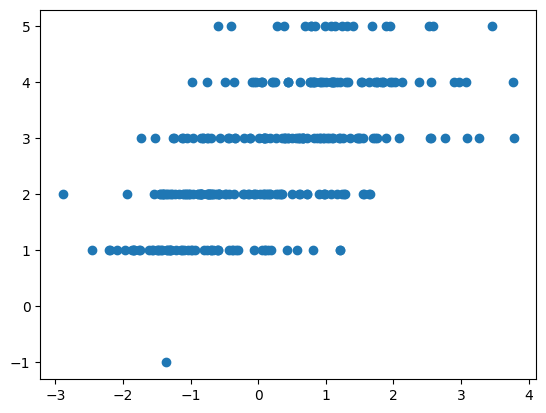

In [6]:
plt.scatter(grid_search_pred_scores, grid_search_actual_scores)

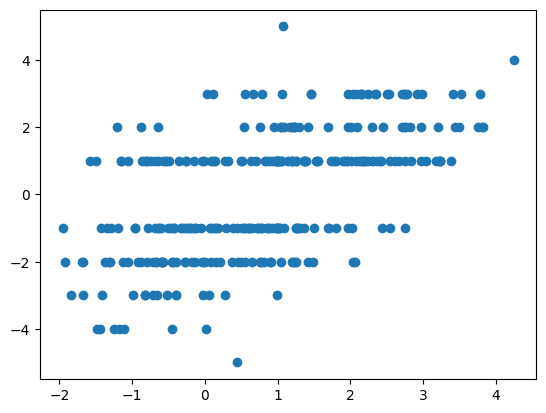

In [7]:
plt.scatter(nn_best_pred_scores, nn_best_actual_scores)

In [10]:
import pandas as pd

score_comparison = pd.DataFrame({
    "state": np.arange(300),
    "grid_search_pred_score": grid_search_pred_scores,
    "grid_search_actual_score": grid_search_actual_scores,
    "grid_search_pred_score_stdev": grid_search_pred_score_stdevs,
    "nn_best_actual_score": nn_best_actual_scores,
    "nn_best_pred_score": nn_best_pred_scores,
    "nn_best_pred_score_stdev": nn_best_pred_score_stdevs
})

In [16]:
(score_comparison["grid_search_actual_score"] - score_comparison["grid_search_pred_score"]).mean()

np.float64(2.4875211347211477)

In [17]:
(score_comparison["nn_best_actual_score"] - score_comparison["nn_best_pred_score"]).mean()

np.float64(-0.7913677465451975)

In [18]:
score_comparison["grid_search_pred_score"].mean()

np.float64(0.1458121986121858)

In [19]:
score_comparison["nn_best_pred_score"].mean()

np.float64(0.7947010798785309)

## NEXT UP: predicting from second to last state

In [209]:
20x20
expected score val r^2 0.79ish

30x30
expected_score_val_r2 = 0.8060334892941788, frac max prob = actual 0.834925
extra layer
expected_score_val_r2 = 0.7993249671623189, frac max prob = actual 0.8349
100x100
expected_score_val_r2 = 0.8282151091910064, frac max prob = actual 0.83515
20x20 with new features
expected_score_val_r2 = 0.8044039307457008, frac max prob = actual 0.82885
100x100 with new features
expected_score_val_r2 = 0.8274895115689724, frac max prob = actual 0.835
100x100 with new features and 30 training iters

SyntaxError: invalid decimal literal (5022038.py, line 1)